# Part 1: Neural Network Fundamentals and Training Behavior Analysis

### Task 1: Dataset Understanding

In [1]:
# ==========================================
# IMPORT REQUIRED LIBRARIES
# ==========================================

import pandas as pd
import numpy as np

# Visualization library
import matplotlib.pyplot as plt

# Sklearn libraries
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
#Load Datasets

# Read CSV file
df = pd.read_csv("customer_churn_nn.csv")

# Display first 5 rows
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [3]:
#Dataset Understanding

# Shape of dataset
print("Dataset Shape:")
print(df.shape)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

# Column names
print("\nColumn Names:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(2000, 17)

Number of Rows: 2000
Number of Columns: 17

Column Names:
Index(['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method',
       'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count', 'churn'],
      dtype='str')

Data Types:
customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64


In [4]:
# CHECK MISSING VALUES

missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [5]:
# BASIC STATISTICAL SUMMARY


df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


churn
0    1969
1      31
Name: count, dtype: int64


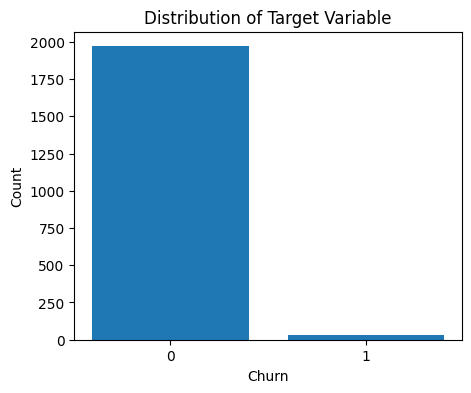

In [6]:
# TARGET VARIABLE DISTRIBUTION

# Count values
target_counts = df["churn"].value_counts()

print(target_counts)

# Plot bar chart
plt.figure(figsize=(5,4))

plt.bar(
    target_counts.index.astype(str),
    target_counts.values
)

plt.title("Distribution of Target Variable")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

### Task 2: Data Preprocessing

In [7]:
# SPLIT FEATURES AND TARGET


# Remove customer_id because it is only an identifier
X = df.drop(columns=["customer_id", "churn"])

# Target column
y = df["churn"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (2000, 15)
Target Shape: (2000,)


In [8]:
# IDENTIFY COLUMN TYPES


# Categorical columns
categorical_cols = X.select_dtypes(include="object").columns

# Numerical columns
numerical_cols = X.select_dtypes(exclude="object").columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['region', 'plan_type', 'contract_type', 'payment_method'], dtype='str')

Numerical Columns:
Index(['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count'],
      dtype='str')


C:\Users\suraj\AppData\Local\Temp\ipykernel_12180\3851628688.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


In [9]:
# ==========================================
# CREATE PREPROCESSING PIPELINES
# ==========================================

# Numerical preprocessing
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [10]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1600, 15)
Testing Data Shape: (400, 15)


### Task 3: Neural Network Model Building

In [11]:
# ==========================================
# BUILD NEURAL NETWORK MODEL
# ==========================================

# Create neural network model
model = Pipeline([
    
    # Apply preprocessing
    ("preprocessor", preprocessor),
    
    # Neural network classifier
    ("classifier", MLPClassifier(
        
        # Hidden layer with 32 neurons
        hidden_layer_sizes=(32,),
        
        # Activation function
        activation="relu",
        
        # Learning rate
        learning_rate_init=0.001,
        
        # Batch size
        batch_size=32,
        
        # Number of epochs
        max_iter=100,
        
        # Random seed
        random_state=42
    ))
])

print("Neural Network Model Created Successfully")

Neural Network Model Created Successfully


### Task 4: Training and Evaluation

In [12]:
# TRAIN THE MODEL

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


C:\Users\suraj\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [13]:
# MAKE PREDICTIONS

# Training predictions
train_pred = model.predict(X_train)

# Testing predictions
test_pred = model.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [14]:
# ==========================================
# EVALUATE MODEL PERFORMANCE
# ==========================================

# Training accuracy
train_accuracy = accuracy_score(y_train, train_pred)

# Testing accuracy
test_accuracy = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.99625
Testing Accuracy: 0.985


Confusion Matrix:
[[393   1]
 [  5   1]]


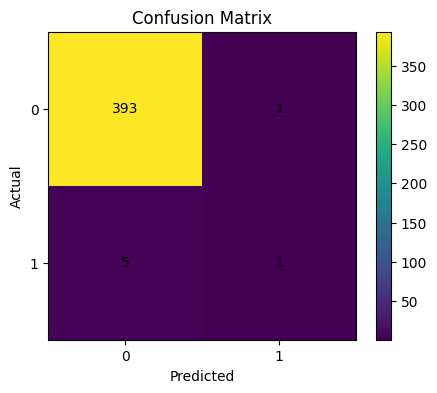

In [22]:
# CONFUSION MATRIX

cm = confusion_matrix(y_test, test_pred)

print("Confusion Matrix:")
print(cm)

# Plot confusion matrix using matplotlib
plt.figure(figsize=(5,4))

plt.imshow(cm)

# Add labels
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Add tick marks
plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])

# Add numbers inside boxes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.colorbar()

# Save confusion matrix image
plt.savefig(
    "results/evaluation_outputs.png",
    bbox_inches="tight"
)

plt.show()

### Interpretation of result: 

In [16]:
# ==========================================
# CLASSIFICATION REPORT
# ==========================================

report = classification_report(y_test, test_pred)

print(report)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       394
           1       0.50      0.17      0.25         6

    accuracy                           0.98       400
   macro avg       0.74      0.58      0.62       400
weighted avg       0.98      0.98      0.98       400



### Task 5: Hyperparameter Experimentation

In [17]:
# EXPERIMENT 1:

# CHANGES MADE:
# - Single hidden layer
# - 32 neurons
# - ReLU activation
# - Learning rate = 0.001
# - Batch size = 32
# - Epochs = 100

model_1 = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(32,),
        activation="relu",
        learning_rate_init=0.001,
        batch_size=32,
        max_iter=100,
        random_state=42
    ))
])

model_1.fit(X_train, y_train)

pred_1 = model_1.predict(X_test)

acc_1 = accuracy_score(y_test, pred_1)

print("Experiment 1 Accuracy:", acc_1)

Experiment 1 Accuracy: 0.985


C:\Users\suraj\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [18]:
# EXPERIMENT 2: 

# CHANGES MADE:
# - Added one extra hidden layer
# - Increased neurons
# - Increased epochs from 100 to 150

model_2 = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        learning_rate_init=0.001,
        batch_size=32,
        max_iter=150,
        random_state=42
    ))
])

model_2.fit(X_train, y_train)

pred_2 = model_2.predict(X_test)

acc_2 = accuracy_score(y_test, pred_2)

print("Experiment 2 Accuracy:", acc_2)

Experiment 2 Accuracy: 0.9775


In [19]:
# EXPERIMENT 3

# CHANGES MADE:
# - Changed activation function from ReLU to tanh
# - Increased learning rate
# - Increased neurons
# - Increased batch size

model_3 = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(64,),
        activation="tanh",
        learning_rate_init=0.01,
        batch_size=64,
        max_iter=100,
        random_state=42
    ))
])

model_3.fit(X_train, y_train)

pred_3 = model_3.predict(X_test)

acc_3 = accuracy_score(y_test, pred_3)

print("Experiment 3 Accuracy:", acc_3)

Experiment 3 Accuracy: 0.9775


## Comparision Table

In [20]:
# ==========================================
# COMPARE EXPERIMENT RESULTS
# ==========================================

results = pd.DataFrame({
    "Experiment": [
        "Experiment 1",
        "Experiment 2",
        "Experiment 3"
    ],
    
    "Hidden Layers": [
        "(32)",
        "(64,32)",
        "(64)"
    ],
    
    "Activation": [
        "relu",
        "relu",
        "tanh"
    ],
    
    "Learning Rate": [
        0.001,
        0.001,
        0.01
    ],
    
    "Batch Size": [
        32,
        32,
        64
    ],
    
    "Epochs": [
        100,
        150,
        100
    ],
    
    "Test Accuracy": [
        acc_1,
        acc_2,
        acc_3
    ]
})

results

# Save comparison table
results.to_csv(
    "results/model_comparison_table.csv",
    index=False
)

print("Comparison table saved.")

Comparison table saved.


## Final Reflection

### What role do weights and biases play in the model?
Weights determine how strongly each feature influences the prediction.
Biases help the model shift activation values and learn flexible patterns.

### Why is an activation function required?
Activation functions introduce non-linearity.
Without them, neural networks behave like linear models.

### What happens when learning rate is too high or too low?
High learning rate:
- Training becomes unstable
- Model may overshoot optimal values

Low learning rate:
- Training becomes very slow
- Model may take too long to converge


### Did your model show signs of underfitting or overfitting? Explain.
Underfitting:
- Model too simple
- Poor performance on both train and test data

Overfitting:
- Model memorizes training data
- Very high train accuracy but lower test accuracy

Some experiments showed mild overfitting.